## Georgia Gingles Analysis

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
demographics = ['white', 'black', 'latino', 'other']
candidates = ['harris', 'trump']

### Path and DataFrame

In [3]:
path = '../output/Georgia/seawulf.csv'

In [4]:
df = pd.read_csv(path)
df = df[df['Total_votes'] > 0]
df = df.reset_index()
df.drop(columns='index', inplace=True)
df

,UNIQUE_ID,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,APPLING-:-1B,108,921,2,1031,1074.216587,102.982480,55.003760,3.618320,1235.821146,"POLYGON ((375680.6717 3535246.721, 375706.5104..."
1,APPLING-:-1C,67,724,0,791,1191.912652,472.673691,42.287709,28.713142,1735.587193,"POLYGON ((378693.0887 3524550.847, 378692.8331..."
2,APPLING-:-2,782,541,4,1327,1235.612661,788.224241,96.849558,32.601383,2153.287844,"POLYGON ((380005.7799 3525000.1826, 380113.838..."
3,APPLING-:-3A1,31,617,0,648,705.543283,121.434717,146.434230,7.825296,981.237527,"POLYGON ((377772.2288 3534595.104, 377753.8538..."
4,APPLING-:-3C,246,934,3,1183,1427.934438,416.186299,57.464584,60.117966,1961.703287,"POLYGON ((386430.8865 3520109.3215, 386469.241..."
...,...,...,...,...,...,...,...,...,...,...,...
2689,WORTH-:-SCOOTERVILLE,33,466,0,499,882.262998,21.675616,59.886046,15.588500,979.413160,"POLYGON ((241750.6763 3468959.4477, 241748.751..."
2690,WORTH-:-SUMNER,115,549,2,666,1053.312665,264.181783,2.612231,59.035993,1379.142672,"POLYGON ((248495.8814 3494258.3435, 248494.668..."
2691,WORTH-:-SYLVESTER,1124,738,4,1866,1166.052147,1077.443185,20.669560,38.311600,2302.476493,"POLYGON ((216948.6246 3494724.9875, 216948.695..."
2692,WORTH-:-SYLVESTER EAST,211,1019,3,1233,1586.468847,147.357490,90.820364,159.706155,1984.352857,"POLYGON ((235331.0428 3502013.0719, 235645.208..."


### Isolate Columns and Create More Columns

In [5]:
def calculate_shares(df):
    df.columns = df.columns.str.lower()

    data = pd.DataFrame()

    data['winning_party'] = np.where(
        df['kamala d. harris'] > df['donald j. trump'], 
        'Democratic', 
        'Republican'
    )

    data['trump_vote_share'] = df['donald j. trump'] / df['total_votes']
    data['harris_vote_share'] = df['kamala d. harris'] / df['total_votes']
    data['total_votes'] = df['total_votes']

    for demographic in demographics:
        data[f'{demographic}_pct'] = (
            df[f'{demographic}_population'] / df['total_population']
        )
    
    return data

In [6]:
gingles = calculate_shares(df)
gingles['id'] = gingles.index + 1
gingles

,winning_party,trump_vote_share,harris_vote_share,total_votes,white_pct,black_pct,latino_pct,other_pct,id
0,Republican,0.893307,0.104753,1031,0.869233,0.083331,0.044508,0.002928,1
1,Republican,0.915297,0.084703,791,0.686749,0.272342,0.024365,0.016544,2
2,Democratic,0.407687,0.589299,1327,0.573826,0.366056,0.044978,0.015140,3
3,Republican,0.952160,0.047840,648,0.719034,0.123757,0.149234,0.007975,4
4,Republican,0.789518,0.207946,1183,0.727905,0.212156,0.029293,0.030646,5
...,...,...,...,...,...,...,...,...,...
2689,Republican,0.933868,0.066132,499,0.900808,0.022131,0.061145,0.015916,2690
2690,Republican,0.824324,0.172673,666,0.763745,0.191555,0.001894,0.042806,2691
2691,Democratic,0.395498,0.602358,1866,0.506434,0.467950,0.008977,0.016639,2692
2692,Republican,0.826440,0.171127,1233,0.799489,0.074260,0.045768,0.080483,2693


### Precincts

In [7]:
def create_precinct_data(gingles):
    precincts = []
    
    for _, row in gingles.iterrows():
        precinct_obj = {
            "id": int(row['id']),
            "harris_vote_share": row['harris_vote_share'],
            "trump_vote_share": row['trump_vote_share'],
            "groups": {
                "black": row['black_pct'],
                "latino": row['latino_pct'],
                "other": row['other_pct'],
                "white": row['white_pct'],
            }
        }
        precincts.append(precinct_obj)

    return precincts

In [8]:
precincts = create_precinct_data(gingles)
print(precincts[0])

{'id': 1, 'harris_vote_share': 0.10475266731328807, 'trump_vote_share': 0.8933074684772065, 'groups': {'black': 0.08333121680756753, 'latino': 0.04450786425677977, 'other': 0.0029278669722729456, 'white': 0.8692330519633796}}


### Non-Linear Regression Line

In [9]:
def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def power(x, a, b):
    return a * np.power(np.clip(x, 1e-6, None), b)

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

MODELS = {
    'sigmoid': (
        sigmoid,
        [1, 5, 0.5],
        ([0, 0, 0], [1, 20, 1])
    ),
    'power': (
        power,
        [0.5, 0.1],
        ([0, 0], [2, 5])
    ),
    'exponential': (
        exponential,
        [0.5, 0.1, 0.1],
        ([0, -5, 0], [2, 5, 1])
    ),
}

FORMULAS = {
    'sigmoid':     'L / (1 + exp(-k * (x - x0)))',
    'power':       'a * x^b',
    'exponential': 'a * exp(b*x) + c',
}

In [10]:
def aic(y, yhat, k):
    n = len(y)
    rss = np.sum((y - yhat) ** 2)
    rss = max(rss, 1e-12)  # prevent log(0)
    return n * np.log(rss / n) + 2 * k

def select_best_model(x, y):
    best_name, best_fn, best_params, best_aic_score = None, None, None, np.inf
    for name, (fn, p0, bounds) in MODELS.items():
        try:
            params, cov = curve_fit(fn, x, y, p0=p0, bounds=bounds)
            yhat = fn(x, *params)
            score = aic(y, yhat, k=len(params))
            if score < best_aic_score:
                best_aic_score = score
                best_name   = name
                best_params = params
                best_fn     = lambda xg, fn=fn, params=params: np.clip(fn(xg, *params), 0, 1)
        except Exception:
            continue
    return best_fn, best_name, best_params

In [11]:
PARAM_LABELS = {
    'sigmoid':     ['L', 'b1', 'b0'], 
    'power':       ['a', 'b'],
    'exponential': ['a', 'b', 'c'],
}

def select_best_models(gingles, demographics):
    fits = {}
    
    for demographic in demographics:
        x = gingles[f'{demographic}_pct'].values.astype(float)
        candidates_data = []

        for cand in ['harris', 'trump']:
            y = gingles[f'{cand}_vote_share'].values.astype(float)
            _, name, raw_params = select_best_model(x, y)
            
            if name:
                if name == 'sigmoid':
                    L, k, x0 = raw_params
                    final_params = [float(L), float(k), float(-k * x0)]
                else:
                    final_params = [float(p) for p in raw_params]

                candidates_data.append({
                    'candidate': cand,
                    'model':     name,
                    'params':    dict(zip(PARAM_LABELS[name], final_params))
                })

        fits[demographic] = candidates_data

    return {'fits': fits}

regression = select_best_models(gingles, demographics)
regression

{'fits': {'white': [{'candidate': 'harris',
    'model': 'exponential',
    'params': {'a': 1.0087596336927587,
     'b': -1.4048460932492806,
     'c': 9.841641565003044e-17}},
   {'candidate': 'trump',
    'model': 'power',
    'params': {'a': 0.8432011895721889, 'b': 0.890510536411767}}],
  'black': [{'candidate': 'harris',
    'model': 'sigmoid',
    'params': {'L': 0.9999999999999994,
     'b1': 3.411818985201052,
     'b0': -1.1098074027255098}},
   {'candidate': 'trump',
    'model': 'exponential',
    'params': {'a': 0.7923666118109021,
     'b': -1.695526841665441,
     'c': 4.4915074440306817e-13}}],
  'latino': [{'candidate': 'harris',
    'model': 'sigmoid',
    'params': {'L': 0.9762681371371128,
     'b1': 1.363613187044103,
     'b0': -6.975184218295062e-16}},
   {'candidate': 'trump',
    'model': 'exponential',
    'params': {'a': 0.13683634746871914,
     'b': -4.999999986715878,
     'c': 0.3789007059521399}}],
  'other': [{'candidate': 'harris',
    'model': 'sigmoi

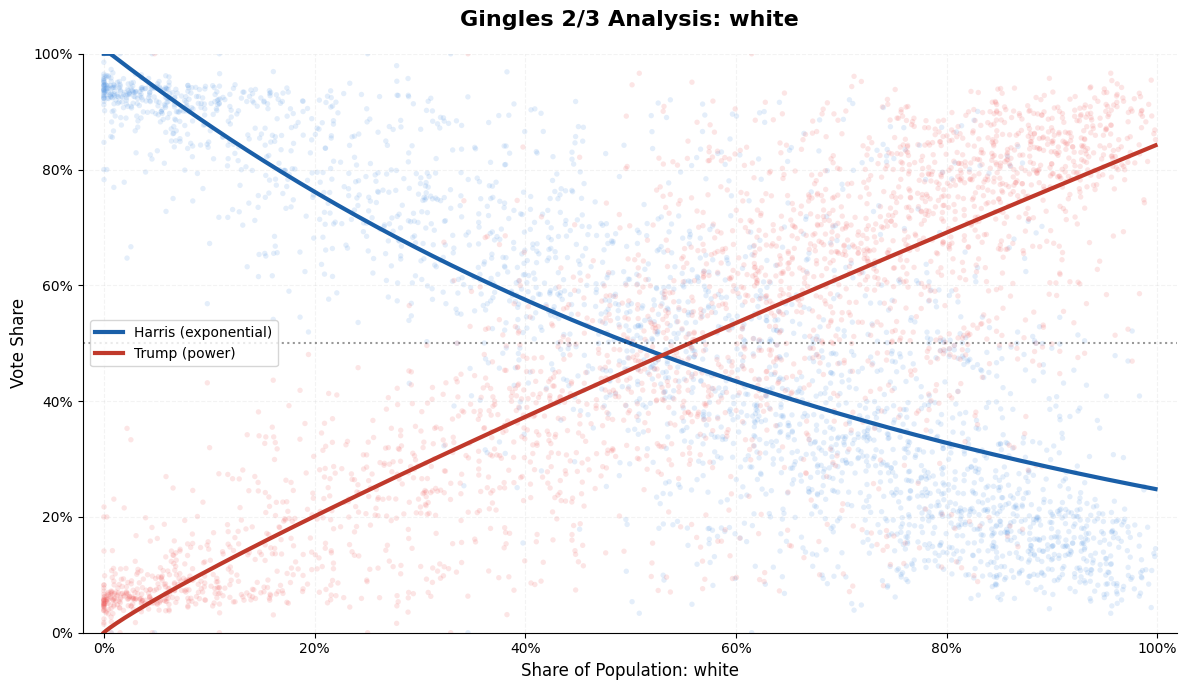

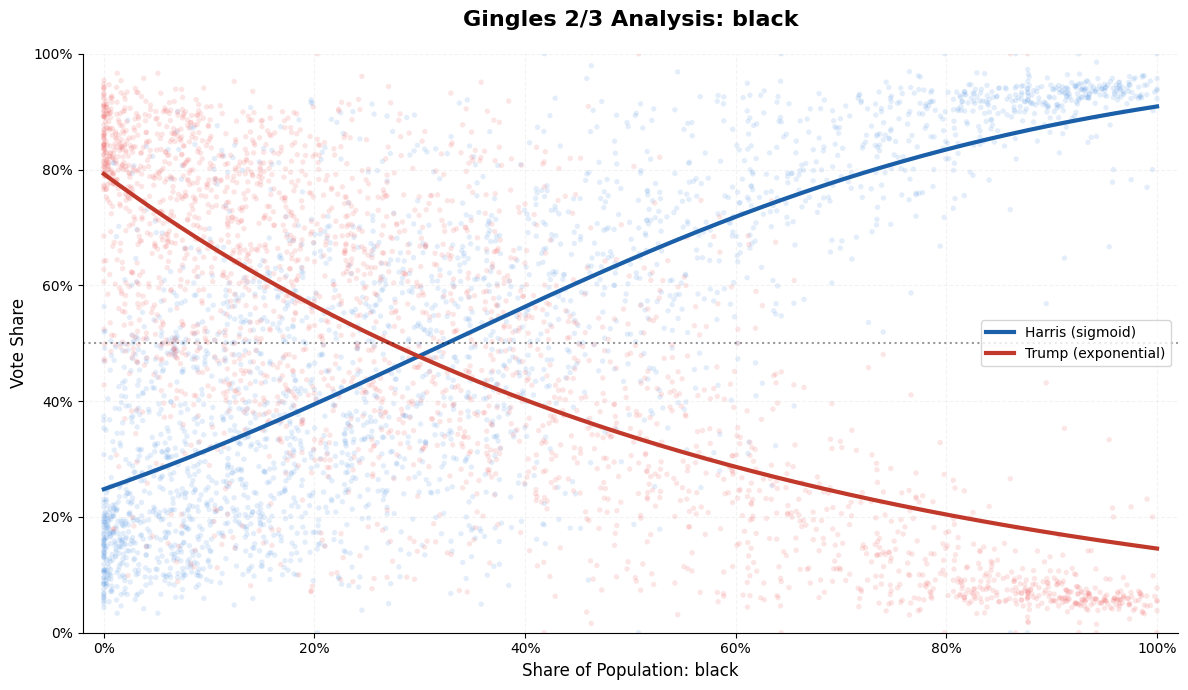

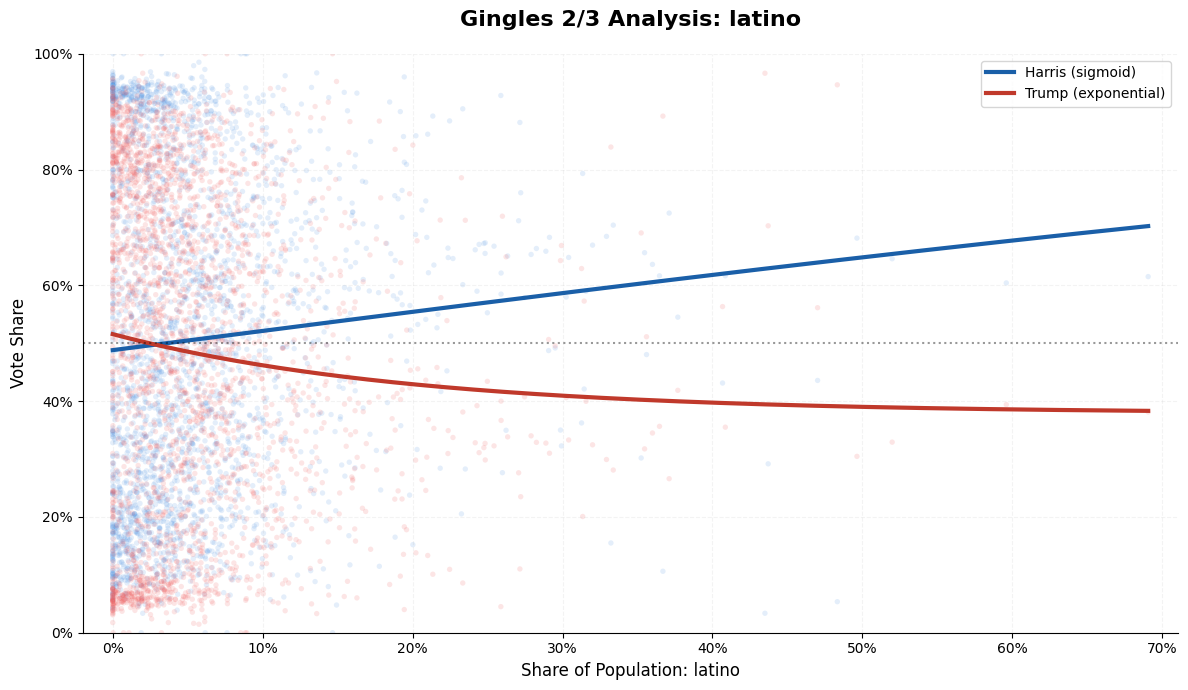

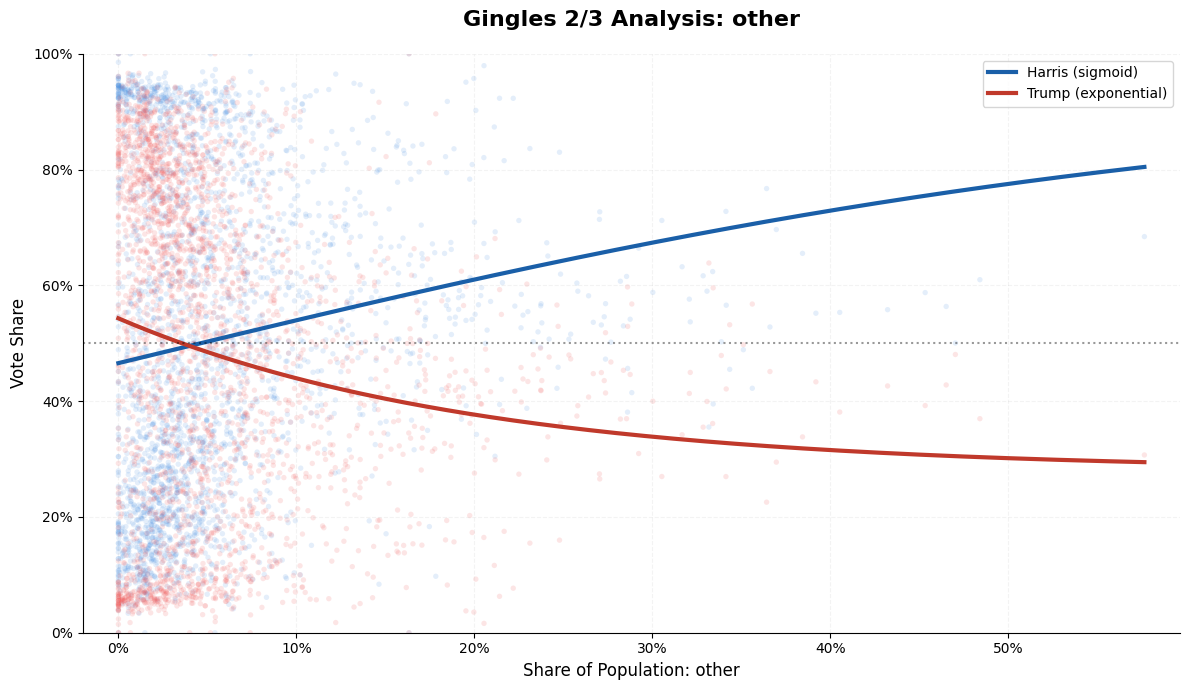

In [12]:
def plot_gingles(result, df, demographic):
    candidateList = result['fits'][demographic]
    harris = next(c for c in candidateList if c['candidate'] == 'harris')
    trump  = next(c for c in candidateList if c['candidate'] == 'trump')

    x  = df[f'{demographic}_pct'].values
    yh = df[f'harris_vote_share'].values
    yt = df[f'trump_vote_share'].values
    x_grid = np.linspace(x.min(), x.max(), 500)

    def get_prediction(cand_dict, x_vals):
        name = cand_dict['model']
        p = cand_dict['params']
        
        if name == 'sigmoid':
            y_pred = p['L'] / (1 + np.exp(-(p['b0'] + p['b1'] * x_vals)))
        else:
            fn = MODELS[name][0]
            y_pred = fn(x_vals, *p.values())
            
        return np.clip(y_pred, 0, 1)

    # --- Plotting Code ---
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

    # Scatter points
    ax.scatter(x, yh, color='#4A90E2', s=15, alpha=0.15, edgecolors='none')
    ax.scatter(x, yt, color='#F05454', s=15, alpha=0.15, edgecolors='none')

    # Trend lines
    ax.plot(x_grid, get_prediction(harris, x_grid), color='#1a5fa8', lw=3, label=f"Harris ({harris['model']})")
    ax.plot(x_grid, get_prediction(trump, x_grid), color='#c0392b', lw=3, label=f"Trump ({trump['model']})")

    ax.axhline(0.5, color='black', linestyle=':', alpha=0.4)
    
    ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
    y_all = np.concatenate([yh, yt])
    ax.set_ylim(max(0, y_all.min() - 0.05), min(1, y_all.max() + 0.05))

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    ax.set_xlabel(f'Share of Population: {demographic}', fontsize=12)
    ax.set_ylabel('Vote Share', fontsize=12)
    ax.set_title(f'Gingles 2/3 Analysis: {demographic}', fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(frameon=True, loc='best')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.15)

    plt.tight_layout()
    plt.show()

for demographic in demographics:
    plot_gingles(regression, gingles, demographic)

In [13]:
results = {}

for d in demographics:
    x = gingles[f'{d}_pct'].values
    
    results[d] = {}
    for c in candidates:
        y = gingles[f'{c}_vote_share'].values
        
        mask = ~np.isnan(x) & ~np.isnan(y)
        corr = np.corrcoef(x[mask], y[mask])[0, 1]
        
        results[d][c] = corr

for d in results:
    print(f"\n{d.upper()}:")
    for c in results[d]:
        print(f"  {c}: {results[d][c]:.4f}")


WHITE:
  harris: -0.8343
  trump: 0.8312

BLACK:
  harris: 0.7799
  trump: -0.7741

LATINO:
  harris: 0.0702
  trump: -0.0747

OTHER:
  harris: 0.1402
  trump: -0.1488


### Save Gingles Data to JSON

In [14]:
def save_to_json(regression, precincts):
    gingles_json = {'state': 'Georgia', 'regression': regression, 'precincts': precincts}

    with open('../output/Georgia/ga_gingles_results.json', 'w') as f:
        json.dump(gingles_json, f, indent=4)

save_to_json(regression, precincts)